In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob, os, yaml, itertools, subprocess, sys, shutil#,sparse

import Bio.SeqUtils
import Bio.Data
from Bio import SeqIO
from Bio.Seq import Seq

plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlepad'] = 10
import scipy.stats as st
import warnings
warnings.filterwarnings("ignore")

# load all utils functions
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "utils"))
# from data_utils import *
from inSilicoMut_utils import *

from matplotlib.ticker import FormatStrFormatter
from sklearn.linear_model import LinearRegression

results_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"
data_path = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"

who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")
who_variants["gene"] = [mut.split("_")[0] for mut in who_variants["mutation"].values]

solo_results = pd.read_excel("/home/sak0914/who-analysis/data/SOLO primary_STATA_ver18Feb2023.xlsx", sheet_name="Sheet1")

df_rif = pd.read_csv(os.path.join(data_path, "RIF/data_for_model.csv"))
df_rif_val = pd.read_csv(os.path.join(data_path, "RIF/validation_data_for_model.csv"))

df_mxf = pd.read_csv(os.path.join(data_path, "MXF/data_for_model.csv"))
df_mxf_val = pd.read_csv(os.path.join(data_path, "MXF/validation_data_for_model.csv"))

h37Rv = SeqIO.read("/n/data1/hms/dbmi/farhat/Sanjana/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")
h37Rv_genes = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/mycobrowser_h37rv_genes_v4.csv")

coll_2014 = pd.read_csv("/home/sak0914/who-analysis/data/coll2014_SNP_scheme.tsv", sep="\t")
coll_2014["lineage"] = coll_2014["#lineage"].str.replace("lineage", "")
del coll_2014["#lineage"]

RIF_isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/rpoBC_variants_10543isolates.csv")
MXF_isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/gyrBA_variants_8569isolates.csv")

h37Rv_seq = SeqIO.read("/n/data1/hms/dbmi/farhat/Sanjana/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")

# Introduce Compatible Mutations from the WHO V1 Catalog into H37Rv and Predict with Model

## Focus on rpoB first, then move on to other genes

In [2]:
def get_VCF_file_information(drug, seq_df_fName, genes_to_analyze, sense, START, END):
    '''
    genes_to_analyze can be a list or a string
    
    START and END are inclusive
    '''
    
    seq_df = pd.read_csv(seq_df_fName).set_index("Isolate")
    seq_df.columns = [int(float(col)) if "." in col else col for col in seq_df.columns]

    # get dictionaries mapping WHO categories to unique sites and dataframes
    sites_dict, dfs_dict = get_dict_WHO_mutations_sites(who_variants, drug, genes_to_analyze)

    # all mutations merged with the saliency dataframe
    genes_ALL = pd.concat([dfs_dict[num] for num in range(1, 6)], axis=0)
    print(genes_ALL.shape)
    
    # get information to write VCF files
    genes_ALL = get_data_for_synthetic_VCF(genes_ALL, sense)
    print(genes_ALL.shape)

    # # merge with the saliency dataframe to get only WHO mutations THAT WERE ALSO IN OUR MODEL (biggest difference is upstream nucleotides, WHO included more)
    # genes_ALL = genes_ALL.merge(saliency_df, left_on="POS", right_on="Pos", how="inner")

    # keep only sites in our alignment
    genes_ALL = genes_ALL.query("POS >= @START & POS <= @END")
    print(genes_ALL.shape)
    return genes_ALL

# rpoB, Rifampicin

In [3]:
# takes a while to run
rpoBC_ALL = get_VCF_file_information("RIF", 
                                     "Rifampicin/rpoBC_seqdf.csv", 
                                     ["rpoB", "rpoC"], 
                                     "pos", 
                                     759611, 
                                     767320
                                    )

(1088, 5)
(1088, 9)
(1057, 9)


In [43]:
len(rpoBC_ALL.mutation.unique())

1027

# gyrA, Moxifloxacin

In [6]:
gyrBA_ALL = get_VCF_file_information("MXF", 
                                     "Moxifloxacin/gyrBA_seqdf.csv", 
                                     #"Moxifloxacin/gyrBA_saliency_results.csv", 
                                     ["gyrA", "gyrB"], 
                                     "pos", 
                                     4998, 
                                     9818
                                    )

(548, 5)
(547, 9)
(547, 9)


In [7]:
len(gyrBA_ALL.mutation.unique())

543

# Write Variants to Synthetic VCF Files and Save a txt file of them

## Both of these components are needed to run <code>06_make_MSA.py</code>

In [5]:
# # then write them to new VCF files
# # this also creates a file of the mutation names

# shutil.rmtree("/n/scratch3/users/s/sak0914/synthetic_VCF")

In [6]:
def remove_mutations_to_preserve_aln(model_aln_df, full_aln_df, START, vcf_df):
    
    print(f"Original aln insertions: {model_aln_df['len_insertion'].sum()}")
    print(f"In silico aln insertions: {full_aln_df['len_insertion'].sum()}")
    
    model_aln_df["name"] = "old"
    full_aln_df["name"] = "new"

    insertions_combined = model_aln_df.merge(full_aln_df, on="idx", how="outer")

    # idx + START + 1 = record.POS
    insertions_combined["POS"] = insertions_combined["idx"] + START
    
    # x = old, y = new
    search_df = insertions_combined.loc[pd.isnull(insertions_combined["name_x"])]

    # 7885 vs. 7814 --> need to remove 71 nucleotides?
    vcf_df["REF_len"] = [len(val) for val in vcf_df["REF"]]
    vcf_df["ALT_len"] = [len(val) for val in vcf_df["ALT"]]

    drop_mutations = vcf_df.query("POS in @search_df.POS & ALT_len > REF_len")[["confidence", "mutation", "POS", "REF", "ALT"]].mutation.values
    print(drop_mutations)
    print(f"Dropped {len(drop_mutations)} mutations to preserve the alignment")

    vcf_df_cleaned = vcf_df.query("mutation not in @drop_mutations")
    print(len(vcf_df.mutation.unique()), len(vcf_df_cleaned.mutation.unique()))
    
    return vcf_df_cleaned

    return search_df

Finished reading 10578 sequences!
     idx  len_insertion
0     27              1
1     37             21
2    226              6
3    753             12
4   1486              3
5   1488              3
6   1491              3
7   1495              3
8   1704              3
9   2202              3
10  2741              6
11  2820              3
12  3182              6
13  3717              1
14  4750              3
15  5636              3
16  6881              3
17  6884             15
18  7002             12
19  7063              6
Aligned region size: 7826

After updating the script:

0     27              1
1     37              1
2    226              6
3    753             12
4   1486              3
5   1488              3
6   1491              3
7   1495              3
8   1704              3
9   2202              3
10  2741              6
11  2820              3
12  3182              6
13  3717              1
14  4750              3
15  5636              3
16  6881              3
17  6884             15
18  7002             12
19  7063              6

In [7]:
# original dataframe of insertions when the original training data and MIC_ML validation data were aligned
rpoB_aln_OLD = pd.DataFrame({"idx": [27, 37, 226, 753, 1486, 1488, 1491, 1495, 1704, 2202, 2741, 2820, 3182, 3717, 4750, 5636, 6881, 6884, 7002, 7063],
                            "len_insertion": [1, 21, 6, 12, 3, 3, 3, 3, 3, 3, 6, 3, 6, 1, 3, 3, 3, 15, 12, 6]
                           })

rpoB_aln_FULL = pd.DataFrame({"idx": [12, 27, 31, 37, 45, 75, 116, 137, 226, 240, 489, 753, 1486, 1488, 1491, 1495, 1524, 1698, 1704, 1719, 2202, 
                                         2741, 2757, 2820, 3182, 3712, 3717, 4750, 5636, 6881, 6884, 7002, 7063],
                                 "len_insertion": [21, 1, 1, 21, 2, 1, 2, 1, 6, 6, 6, 12, 3, 3, 3, 3, 3, 9, 3, 18, 3, 6, 6, 3, 6, 1, 1, 3, 3, 3, 15, 12, 6]
                                })

rpoBC_aln_2 = pd.DataFrame({"idx": [27, 37, 226, 753, 1486, 1488, 1491, 1495, 1704, 2202, 2741, 2820, 3182, 3717, 4750, 5636, 6881, 6884, 7002, 7013, 7063],
                              "len_insertion": [1, 21, 6, 12, 3, 3, 3, 3, 3, 3, 6, 3, 6, 1, 3, 3, 3, 15, 12, 6, 6]
                             })

In [8]:
rpoBC_ALL_NEW = remove_mutations_to_preserve_aln(rpoB_aln_OLD, rpoB_aln_FULL, 759611, rpoBC_ALL)

Original aln insertions: 116
In silico aln insertions: 193
['rpoB_p.Thr444dup' 'rpoB_c.-121_-120insT' 'rpoB_c.-151_-150insGT'
 'rpoB_c.-165_-164insG' 'rpoB_c.-180_-179insCTTGACACCGTGGTCTTAGTC'
 'rpoB_p.Pro15_Ser16insSerPro' 'rpoB_c.-42_-41insT' 'rpoB_c.-59_-58insT'
 'rpoB_p.Arg499_Asn501dup' 'rpoB_p.Phe503_Thr508dup'
 'rpoB_p.Met97_Ser98dup' 'rpoB_c.-80_-79insTT' 'rpoB_p.Asp853_Glu854dup']
Dropped 13 mutations to preserve the alignment
1027 1014


In [9]:
rpoBC_ALL_NEW = remove_mutations_to_preserve_aln(rpoB_aln_FULL, rpoBC_aln_2, 759611, rpoBC_ALL_NEW)

Original aln insertions: 193
In silico aln insertions: 122
['rpoC_p.Gln1084_Arg1085dup']
Dropped 1 mutations to preserve the alignment
1014 1013


In [17]:
len(rpoBC_ALL.mutation.unique()), len(rpoBC_ALL_NEW.mutation.unique())

(1027, 1013)

In [71]:
rpoBC_ALL_summary = rpoBC_ALL.groupby("mutation")[["POS", "REF", "ALT"]].agg(lambda x: ','.join(x.astype(str)))

rpoBC_ALL_summary["gene"] = [val.split("_")[0] for val in rpoBC_ALL_summary.index.values]
rpoBC_ALL_summary["variant"] = ["_".join(val.split("_")[1:]) for val in rpoBC_ALL_summary.index.values]
rpoBC_ALL_summary["included?"] = 1

rpoBC_ALL_summary = rpoBC_ALL_summary.merge(rpoBC_ALL[["mutation", "confidence"]].drop_duplicates(), left_index=True, right_on="mutation", how="left").set_index("mutation")

In [75]:
rpoBC_ALL_summary.gene.value_counts()

gene
rpoB    724
rpoC    303
Name: count, dtype: int64

In [76]:
rpoBC_ALL_summary.to_csv("Rifampicin/insilico_mutagenesis/rpoBC_WHO_mutation_summary.csv")

In [38]:
# then write them to new VCF files
# this also creates a file of the mutation names
create_synthetic_VCF_files(rpoBC_ALL_NEW, 
                           "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/inSilico_analysis/rpoBC_WHO_mutations.txt", 
                           "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/inSilico_analysis/synthetic_VCF"
                          )

Creating synthetic VCF files for 1014 mutations


In [174]:
len(rpoBC_ALL.mutation.unique()), len(rpoBC_ALL_NEW.mutation.unique())

(1027, 1013)

In [175]:
rpoBC_ALL_NEW.drop_duplicates("mutation").gene.value_counts()

gene
rpoB    711
rpoC    302
Name: count, dtype: int64

In [24]:
# RIF_genos = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/who-mutation-catalogue/Rifampicin/genos_1.csv.gz",
#                         compression="gzip",
#                         usecols=["resolved_symbol", "variant_category", "predicted_effect"]
#                        ).drop_duplicates()

# RIF_genos["mutation"] = RIF_genos["resolved_symbol"] + "_" + RIF_genos["variant_category"]

In [11]:
# original dataframe of insertions when the original training data and MIC_ML validation data were aligned
mxf_aln_OLD = pd.DataFrame({"idx": [77, 78, 79, 80, 83, 124, 2160],
                             "len_insertion": [1, 2, 2, 1, 1, 1, 3]
                            })

mxf_aln_FULL = pd.DataFrame({"idx": [77, 78, 79, 80, 83, 124, 182, 2160],
                             "len_insertion": [1, 2, 2, 1, 1, 1, 2, 3]
                            })

gyrBA_ALL_NEW = remove_mutations_to_preserve_aln(mxf_aln_OLD, mxf_aln_FULL, 4997, gyrBA_ALL)

Original aln insertions: 11
In silico aln insertions: 13
['gyrB_c.-60_-59insG' 'gyrB_c.-60_-59insGC']
Dropped 2 mutations to preserve the alignment
543 541


In [49]:
# # then write them to new VCF files
# # this also creates a file of the mutation names
# create_synthetic_VCF_files(gyrBA_ALL_NEW, 
#                            "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/inSilico_analysis/gyrBA_WHO_mutations.txt", 
#                            "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/inSilico_analysis/synthetic_VCF"
#                           )

Creating synthetic VCF files for 541 mutations


In [12]:
len(gyrBA_ALL.mutation.unique()), len(gyrBA_ALL_NEW.mutation.unique())

(543, 541)

In [128]:
# MXF_genos = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/who-mutation-catalogue/Moxifloxacin/genos_1.csv.gz",
#                         compression="gzip",
#                         usecols=["resolved_symbol", "variant_category", "predicted_effect"]
#                        ).drop_duplicates()

# MXF_genos["mutation"] = MXF_genos["resolved_symbol"] + "_" + MXF_genos["variant_category"]

# Align Synthetic VCF Files to the Training/Validation Isolates

## Example:
```bash
python3 -u data_processing/06_make_MSA.py /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/combined_paths_for_aln.txt /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/inSilico_analysis/rpoB_WHO_mutations.txt 759610 767320 "POS" /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/inSilico_analysis/rpoBC.fasta
```

# Predict MICs for Synthetic Sequences (single mutations inserted into H37Rv), using script

In [18]:
RIF_lineage_pred = pd.read_csv("Rifampicin/insilico_mutagenesis/lineage_predictions.csv")
MXF_lineage_pred = pd.read_csv("Moxifloxacin/insilico_mutagenesis/lineage_predictions.csv")

RIF_pred = pd.read_csv("Rifampicin/insilico_mutagenesis/rpoBC_WHO_predictions.csv")
MXF_pred = pd.read_csv("Moxifloxacin/insilico_mutagenesis/gyrBA_WHO_predictions.csv")

RIF_pred["MIC"] = np.exp2(RIF_pred["CNN_log_MIC"])
MXF_pred["MIC"] = np.exp2(MXF_pred["CNN_log_MIC"])

# for i, row in RIF_pred.iterrows():

#     if "_p" in row["mutation"]:

#         num = []
#         for char in row["mutation"].split("_")[1]:
#             if char.isnumeric():
#                 num.append(char)
#         RIF_pred.loc[i, "codon_num"] = int("".join(num))
#     else:
#         RIF_pred.loc[i, "codon_num"] = 0

# RIF_pred["codon_num"] = RIF_pred["codon_num"].astype(int)

# RIF_pred["gene"] = [val.split("_")[0] for val in RIF_pred["mutation"].values]
print(RIF_pred.gene.unique())
combined_lineage_pred = RIF_lineage_pred.rename(columns={"pred_log2_MIC": "Rifampicin"}).merge(MXF_lineage_pred.rename(columns={"pred_log2_MIC": "Moxifloxacin"}))
# RIF_results = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/who-mutation-catalogue/Rifampicin/BINARY/tiers=1/phenos=ALL/dropAF_noSyn_unpooled/model_analysis.csv")
# del RIF_results["confidence"]

# df_rif_pred = df_rif_pred.merge(RIF_results, on="mutation", how="left")

# RIF_insilico_annotated = df_rif_pred.merge(rpoB_ALL_NEW[["mutation", "REF", "ALT", "REF_len", "ALT_len"]], on="mutation", how="left")
# RIF_insilico_annotated = RIF_insilico_annotated.merge(RIF_genos[["mutation", "predicted_effect"]], on="mutation", how="left").reset_index(drop=True)

['rpoB' 'rpoC' 'MT']


In [21]:
# only keep codons with at least 2 mutations at the site, otherwise the MIC difference will be 0
RIF_codon_summary = pd.DataFrame(RIF_pred.query("codon_num != 0")["codon_num"].value_counts()).reset_index().query("count >= 3")

RIF_codon_summary = RIF_codon_summary.merge(pd.DataFrame(RIF_pred.query("codon_num != 0").groupby("codon_num")["MIC"].max()), left_on="codon_num", right_index=True).rename(columns={"MIC": "Max_MIC"})

RIF_codon_summary = RIF_codon_summary.merge(pd.DataFrame(RIF_pred.query("codon_num != 0").groupby("codon_num")["MIC"].min()), left_on="codon_num", right_index=True).rename(columns={"MIC": "Min_MIC"})

RIF_codon_summary["MIC_diff"] = RIF_codon_summary["Max_MIC"] - RIF_codon_summary["Min_MIC"]
assert RIF_codon_summary.MIC_diff.min() > 0

In [23]:
# sns.scatterplot(data=RIF_codon_summary,
#                 x="count",
#                 y="MIC_diff"
#                )

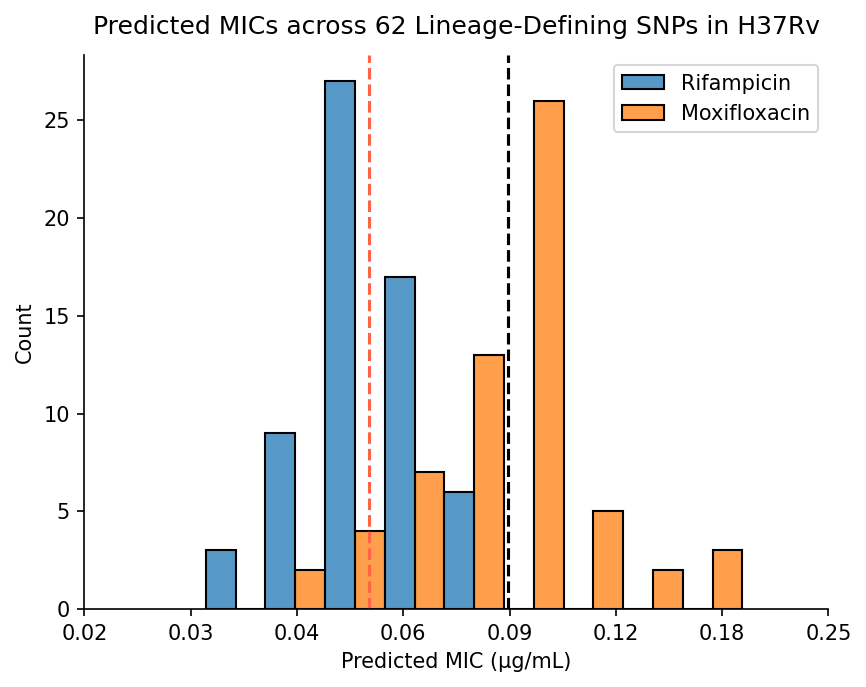

In [23]:
fig, ax = plt.subplots()
sns.histplot(data=combined_lineage_pred.melt(id_vars="Lineage").query("Lineage!='MT_H37Rv'"),
             x="value",
             hue="variable",
             multiple="dodge",
             common_bins=True
            )

ax.legend_.set_title(None)
ax.set_xticks(ticks=ax.get_xticks(), labels=np.round(np.exp2(ax.get_xticks()), 2))
plt.xlabel("Predicted MIC (µg/mL)")
plt.title("Predicted MICs across 62 Lineage-Defining SNPs in H37Rv")

plt.axvline(x=combined_lineage_pred.Rifampicin.mean(), label=f"Rifampicin, No SNP = {np.round(np.exp2(combined_lineage_pred.Rifampicin.mean()), 2)}", linestyle="--", color="tomato")
plt.axvline(x=combined_lineage_pred.Moxifloxacin.mean(), label=f"Moxifloxacin, No SNP = {np.round(np.exp2(combined_lineage_pred.Moxifloxacin.mean()), 2)}", linestyle="--", color="black")
# plt.legend()
sns.despine()
#plt.savefig("RIF_MXF_lineage_predictions.png", dpi=300)

In [64]:
# Wilcoxon signed-rank test
st.wilcoxon(combined_lineage_pred["RIF"], combined_lineage_pred["MXF"], alternative="less")

WilcoxonResult(statistic=54.0, pvalue=3.2626037116283514e-11)

In [25]:
np.mean(combined_lineage_pred["RIF"]), np.mean(combined_lineage_pred["MXF"])

(-4.163097501587302, -3.5059856190476184)

In [66]:
np.exp2(np.mean(combined_lineage_pred["RIF"]))

0.055819093225563644

In [33]:
st.normaltest(combined_lineage_pred["RIF"]), st.normaltest(combined_lineage_pred["MXF"])

(NormaltestResult(statistic=5.7168849348602535, pvalue=0.0573580277252589),
 NormaltestResult(statistic=4.365429647567953, pvalue=0.11273505900096956))

In [60]:
def plot_insilico_lineage_pred(drug, plot_log=True, mic_col="pred_log2_MIC", save=False):

    df = pd.read_csv(f"{drug}/insilico_mutagenesis/lineage_predictions.csv")

    if mic_col not in df.columns:
        raise ValueError(f"{mic_col} is not a valid column name!")
        
    df["pred_MIC"] = np.exp2(df[mic_col])

    if plot_log:
        y_var = mic_col
    else:
        y_var = "pred_MIC"
        
    ref_lineage_mic = df.query("Lineage=='MT_H37Rv'")[y_var].values[0]

    fig, ax = plt.subplots()
    sns.histplot(data=df, x=y_var, stat="probability")

    if plot_log:
        ref_label = np.round(np.exp2(ref_lineage_mic), 2)
    else:
        ref_label = np.round(ref_lineage_mic, 2)
        
    plt.axvline(x=ref_lineage_mic, color="red", label=f"No SNP = {ref_label}", linestyle="--", linewidth=1)
    
    if plot_log:
        ax.set_xticks(ticks=ax.get_xticks(), labels=np.round(np.exp2(ax.get_xticks()), 3))
        
    plt.xlabel("MIC (µg/mL)")
    plt.title(f"Predicted {drug} MICs for H37Rv + Lineage SNPs")
    
    plt.legend()
    sns.despine()

    if save:
        plt.savefig(f"{drug}/insilico_mutagenesis/lineage_predictions.png", dpi=300)
    else:
        plt.show()

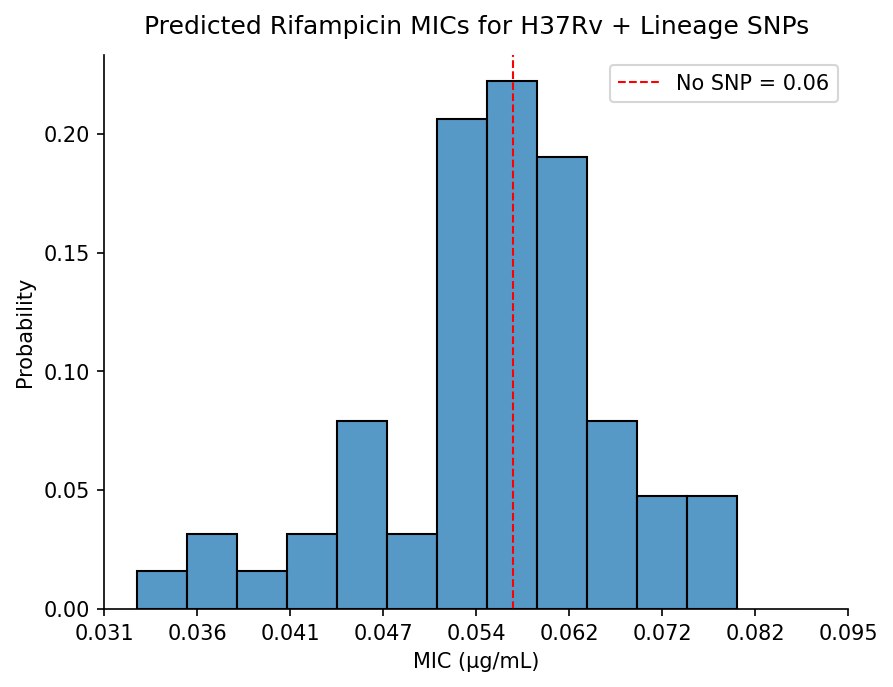

In [61]:
plot_insilico_lineage_pred("Rifampicin", plot_log=True, save=True)

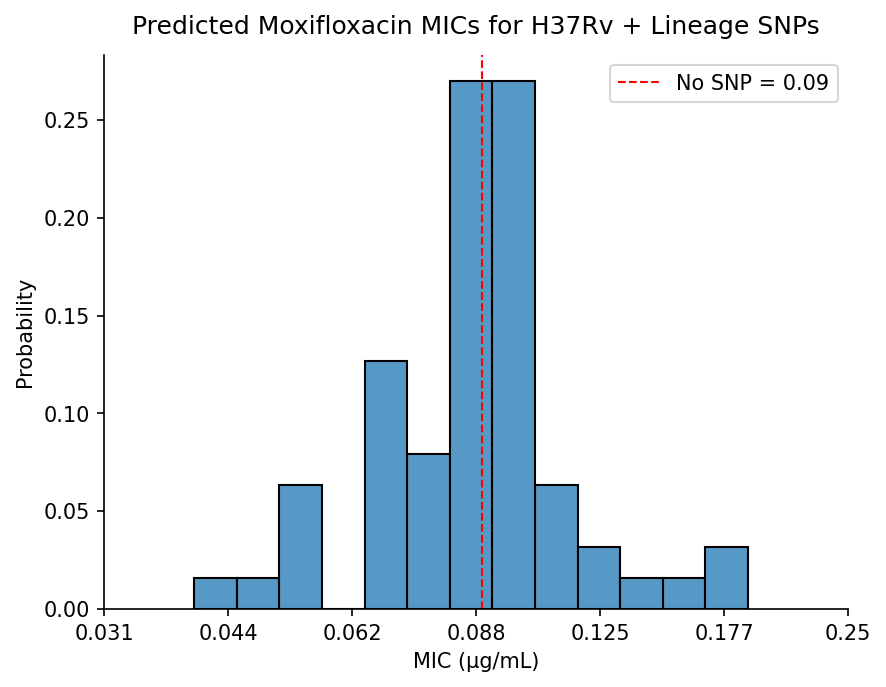

In [62]:
plot_insilico_lineage_pred("Moxifloxacin", plot_log=True, save=True)

# rpoB Mutations Outside the RRDR

In [59]:
df_rif_pred.query("gene == 'rpoB' & ~(codon_num >= 426 & codon_num <= 452) & MIC > 0.5")

,log_MIC,mutation,confidence,genome_index,MIC,codon_num,gene,predicted_effect,position,coef,...,NPV_LB,NPV_UB,Sens_LB,Sens_UB,Spec_LB,Spec_UB,LR+_LB,LR+_UB,LR-_LB,LR-_UB
6,0.967731,rpoB_p.Ile491Phe,1) Assoc w R,761277,1.955762,491,rpoB,missense_variant,761276;761277,0.223670,...,0.647344,0.655973,0.005699,0.008289,0.996477,0.997705,1.828874,3.185632,0.994545,0.997345
7,3.970376,rpoB_p.Val170Phe,1) Assoc w R,760314,15.674807,170,rpoB,missense_variant,760314,0.274420,...,0.647619,0.656236,0.004223,0.006496,0.999819,0.999999,22.581179,1163.662093,0.993657,0.995870
991,0.039532,rpoB_p.Ile491Tyr,3) Uncertain significance,"761277,761278",1.027780,491,rpoB,missense_variant,761277,0.058288,...,0.646469,0.655085,0.000037,0.000531,0.999880,1.000000,NaN,inf,0.999613,1.000024


# Putative Compensatory Mutations in rpoC

## All rpoC mutations predicted not to increase MIC much

In [25]:
RIF_pred.query("gene == 'rpoC'").MIC.max() - RIF_pred.query("gene == 'rpoC'").MIC.min()

0.016147594913294178

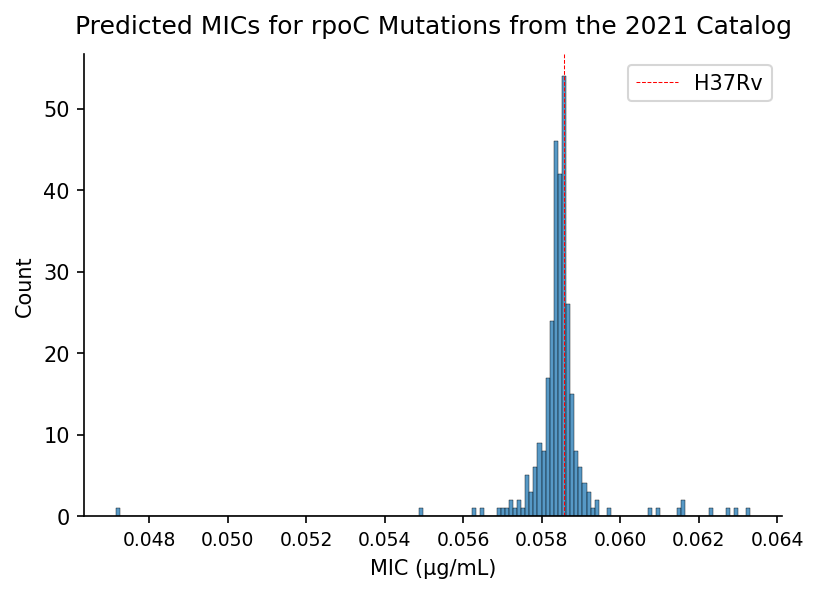

In [59]:
plt.figure(figsize=(6, 4))
sns.histplot(data=RIF_pred.query("gene == 'rpoC'").MIC)#, log_scale=2)
plt.axvline(x=RIF_pred.query("mutation=='MT_H37Rv'")["MIC"].values[0], color="red", linestyle="--", linewidth=0.5, label="H37Rv")

plt.xlabel("MIC (µg/mL)")
plt.xticks(fontsize="9")
plt.title("Predicted MICs for rpoC Mutations from the 2021 Catalog")
plt.legend()
sns.despine()

plt.savefig("Rifampicin/insilico_mutagenesis/rpoC_pred_hist.png", dpi=300)
# plt.show()

In [55]:
RIF_pred.query("gene=='rpoC' & MIC < 0.048")

,CNN_log_MIC,mutation,confidence,genome_index,codon_num,gene,Reg_log_MIC,MIC
1001,-4.406302,rpoC_p.Pro601Leu,5) Not assoc w R,765171,601,rpoC,-4.361765,0.04716


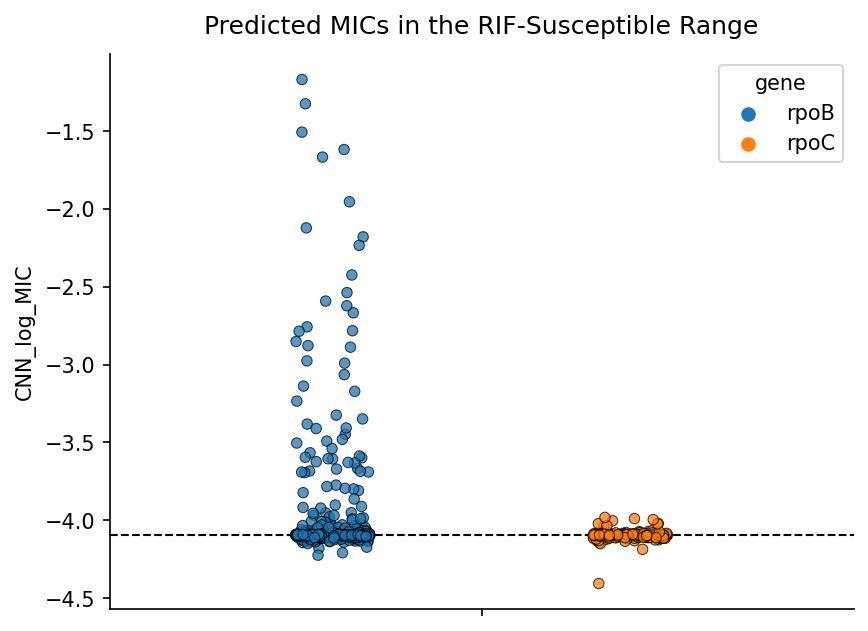

In [29]:
sns.stripplot(data=RIF_pred.query("MIC < 0.5 & gene != 'MT'"),
              y="CNN_log_MIC",
              hue="gene",
              dodge=True,
              alpha=0.75,
              edgecolor="black",
              linewidth=0.5
             )

plt.axhline(y=RIF_pred.query("mutation=='MT_H37Rv'")["CNN_log_MIC"].values[0], color="black", linestyle="--", linewidth=1)
plt.title("Predicted MICs in the RIF-Susceptible Range")
sns.despine()
plt.show()

In [9]:
def create_ECDF_by_mutation_type(annotated_df, save_fName=None):
    
    for i, row in annotated_df.iterrows():

        if pd.isnull(row["predicted_effect"]):

            if "c." in row["mutation"]:
                annotated_df.loc[i, "predicted_effect"] = "upstream_gene_variant"
            elif "p." in row["mutation"]:

                # missense variant
                if row["REF_len"] == row["ALT_len"]:
                    annotated_df.loc[i, "predicted_effect"] = "missense_variant"
                else:
                    # insertions
                    if row["ALT_len"] > row["REF_len"]:
                        # inframe: take length difference and if mod 3 = 0
                        if (row["ALT_len"] - row["REF_len"] ) % 3 == 0:
                            annotated_df.loc[i, "predicted_effect"] = "inframe_insertion"
                        else:
                            annotated_df.loc[i, "predicted_effect"] = "frameshift"
                    else:
                        # inframe: take length difference and if mod 3 = 0
                        if (row["REF_len"] - row["ALT_len"]) % 3 == 0:
                            annotated_df.loc[i, "predicted_effect"] = "inframe_deletion"
                        else:
                            annotated_df.loc[i, "predicted_effect"] = "frameshift"

    assert len(annotated_df.loc[pd.isnull(annotated_df["predicted_effect"])]) == 0
    
    df_plot = annotated_df.drop_duplicates("mutation", keep="first")

    df_plot["predicted_effect"] = df_plot["predicted_effect"].replace("missense_variant", 
                                        "missense"
                                       ).replace("inframe_insertion", 
                                                 "inframe insertion"
                                                ).replace("inframe_deletion",
                                                          "inframe deletion"
                                                         ).replace("upstream_gene_variant",
                                                                   "upstream noncoding"
                                                                  )

    fig, ax = plt.subplots(figsize=(4.5, 4))
    sns.ecdfplot(data=df_plot, x="log_MIC", 
                 hue="predicted_effect", 
                 hue_order=df_plot.groupby("predicted_effect")["log_MIC"].mean().sort_values(ascending=False).index.values,
                 palette="colorblind", 
                 ax=ax
                )

    ax.set_xticks(ticks=ax.get_xticks(), labels=np.round(2**(ax.get_xticks()), 2).astype(str))
    plt.xlabel("Predicted MIC (µg/mL)",  fontsize=8)
    plt.ylabel("Proportion",  fontsize=8)
    plt.title(f"Predicted MICs of {len(df_plot)} WHO Catalog Mutations\n", fontsize=10)

    plt.xlim(df_plot["log_MIC"].min()*1.1, df_plot["log_MIC"].max())

    # fig.legend(labels=df["confidence"].unique())
    sns.move_legend(ax, fontsize=8, title='', loc='lower right')
    # ax.legend(loc='center right', bbox_to_anchor=(1.0, 1.0), fontsize=4, title='')
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    sns.despine()
    
    if save_fName is None:
        plt.show()
    else:
        plt.savefig(save_fName, dpi=300)

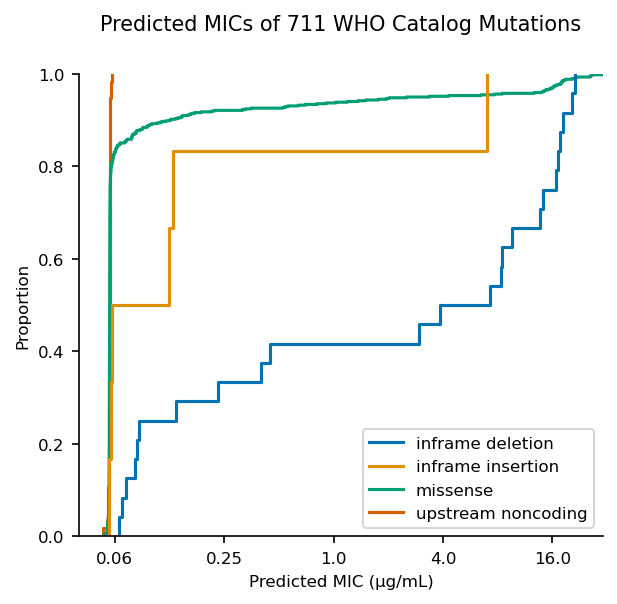

In [28]:
create_ECDF_by_mutation_type(RIF_insilico_annotated)#, "Rifampicin/insilico_mutagenesis/mutations_by_type.png")

# Plot Distribution of Predicted MICs

In [22]:
def plot_ECDF(df, col="CNN_log_MIC", saveName=None):

    df = df.loc[~pd.isnull(df["confidence"])]
    df["MIC"] = 2**(df[col])
    print(df.groupby("confidence")["MIC"].mean())
    
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.ecdfplot(data=df, 
                 x=col, 
                 hue="confidence", 
                 hue_order=np.sort(df["confidence"].unique()),
                 palette="colorblind", 
                 ax=ax,
                 zorder=3
                )
    # ax.get_legend().remove()

    ax.set_xticks(ticks=ax.get_xticks(), labels=np.round(2**(ax.get_xticks()), 2))
    ax.set_yticks(ticks=ax.get_yticks(), labels=(ax.get_yticks()*100).astype(int))

    for percentile in [0.25, 0.5, 0.75]:
        plt.axhline(y=percentile, linestyle='--', color="lightgray", linewidth=1, zorder=0)
    
    plt.xlabel("Predicted MIC (µg/mL)",  fontsize=8)
    plt.ylabel("Percentile",  fontsize=8)
    plt.title(f"Predicted MICs of {len(df)} WHO Catalog Mutations\n", fontsize=10)
    
    y = df[col]
    plt.xlim(y.min()*1.1, y.max()*1.1)

    # fig.legend(labels=df["confidence"].unique())
    sns.move_legend(ax, fontsize=8, title='', loc='upper right', bbox_to_anchor=(1.5, 0.6))
    # ax.legend(loc='center right', bbox_to_anchor=(1.0, 1.0), fontsize=4, title='')
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    sns.despine()
    
    if saveName is not None:
        plt.savefig(saveName, dpi=300, bbox_inches='tight')
    else:
        plt.show()

In [21]:
MXF_pred.loc[~pd.isnull(MXF_pred["CNN_log_MIC"])]

,CNN_log_MIC,Reg_log_MIC,mutation,confidence,genome_index,MIC
0,0.214592,1.300758,gyrA_p.Gly88Cys,1) Assoc w R,7563,1.160376
1,0.323443,11.587188,gyrA_p.Asp94Gly,1) Assoc w R,7582,1.251314
2,0.075687,6.934284,gyrA_p.Ala90Val,1) Assoc w R,7570,1.053863
3,-0.357026,11.587188,gyrA_p.Asp94Ala,1) Assoc w R,7582,0.780772
4,0.721871,5.486968,gyrA_p.Asp94Asn,1) Assoc w R,7581,1.649320
...,...,...,...,...,...,...
537,-3.536171,-3.760984,gyrA_p.Ser95Thr,5) Not assoc w R,7585,0.086200
538,-3.453464,-3.760984,gyrA_p.Gly668Asp,5) Not assoc w R,9304,0.091286
539,-3.467405,-4.482937,gyrA_p.Glu21Gln,5) Not assoc w R,7362,0.090408
540,-3.476225,-3.181575,gyrB_p.Val301Leu,5) Not assoc w R,6140,0.089857


confidence
1) Assoc w R                  1.089806
2) Assoc w R - Interim        0.151980
3) Uncertain significance     0.093522
4) Not assoc w R - Interim    0.261522
5) Not assoc w R              0.089550
Name: MIC, dtype: float64


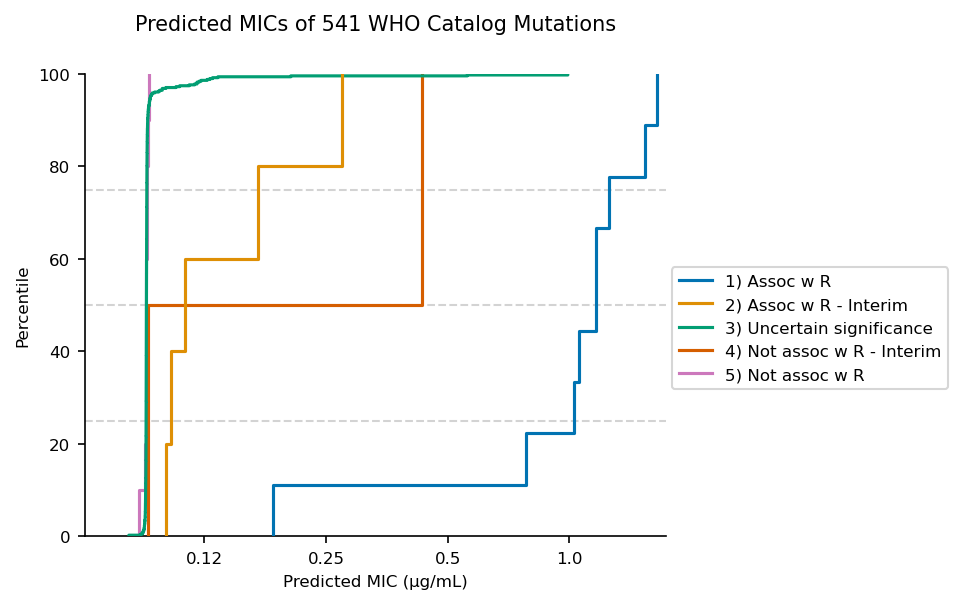

In [23]:
plot_ECDF(MXF_pred)#.query("gene=='rpoB'"), saveName="Rifampicin/insilico_mutagenesis/WHO_rpoB_ECDF.png")

confidence
1) Assoc w R                 12.505758
2) Assoc w R - Interim        4.485013
3) Uncertain significance     0.060856
5) Not assoc w R              0.059294
Name: MIC, dtype: float64


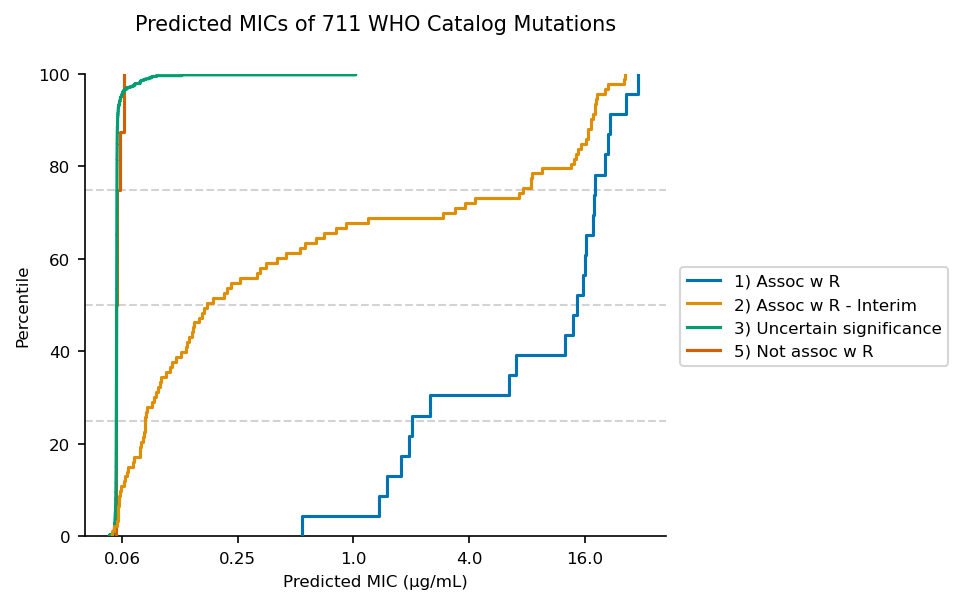

In [56]:
plot_ECDF(RIF_pred.query("gene=='rpoB'"), saveName="Rifampicin/insilico_mutagenesis/WHO_rpoB_ECDF.png")

In [167]:
def get_lineage_MIC_predictions(drug, 
                                config_file,
                               ):
    
    # load in previously trained model
    kwargs = yaml.safe_load(open(config_file, "r"))
    filter_size = kwargs["filter_size"]
    N_epochs = kwargs["N_epochs"]
    BATCH_SIZE = kwargs["batch_size"]

    output_path = kwargs["output_path"]
    binary_thresh = kwargs["binary_thresh"]
    loss_type = kwargs["loss_type"]
    binary = kwargs["binary"]
    bounded_loss = kwargs["bounded_loss"]
    
    lineages = coll_2014.copy()
    lineages["Count"] = 1
    lineages = lineages.pivot(index="lineage", columns="position", values="Count").fillna(0).astype(int)
    
    num_lineages = lineages.shape[1]
    assert np.min(lineages.sum(axis=1).values) == 1
    assert np.max(lineages.sum(axis=1).values) == 1
    
    # add reference lineage, which is all 0s
    lineages = pd.concat([lineages, pd.DataFrame(np.zeros((1, lineages.shape[1])), columns=lineages.columns, index=["H37Rv"])])

    # get longest locus from the pickle file
    X_h37rv = sparse.load_npz(os.path.join(output_path, 'pkl_sparse_ref.npz')).todense()
    
    # copy so that there is one reference sequence for each lineage
    X = np.repeat(X_h37rv, lineages.shape[0], axis=0)

    # shape = 1 x 5 x longest_locus x num_loci
    longest_locus = X_h37rv.shape[2]
    num_loci = X_h37rv.shape[-1]
    del X_h37rv

    best_model = conv_nn(binary, longest_locus, num_loci, num_lineages, bounded_loss, filter_size)
    best_model.load_weights(os.path.join(output_path, "best_model.h5"))

    # X and df_genos are in the same order because df_genos is passed in as an argument to the function to make X
    predicted_mics = best_model.predict([X, lineages.values, np.zeros(X.shape[0]), np.zeros(X.shape[0])], batch_size=BATCH_SIZE).flatten()
    
    df_results = pd.DataFrame({"Lineage": lineages.index.values, "pred_log2_MIC": predicted_mics}).sort_values("pred_log2_MIC", ascending=False).reset_index(drop=True)
    ref_pred = df_results.query("Lineage=='H37Rv'")["pred_log2_MIC"].values[0]
    df_results["H37Rv_diff"] = df_results["pred_log2_MIC"] - ref_pred
    
    return df_results

In [40]:
# RIF_lineage_pred = get_lineage_MIC_predictions("RIF", 
#                                                 "../config_rif_lineage.yaml",
#                                                )

# MXF_lineage_pred = get_lineage_MIC_predictions("MXF", 
#                                                 "../config_mxf_lineage.yaml",
#                                                )


# RIF_lineage_pred.to_csv("Rifampicin/insilico_mutagenesis/lineage_predictions.csv", index=False)
# MXF_lineage_pred.to_csv("Moxifloxacin/insilico_mutagenesis/lineage_predictions.csv", index=False)

In [2]:
import pandas as pd

In [3]:
df_rif_lineage_pred = pd.read_csv("Rifampicin/insilico_mutagenesis/lineage_predictions.csv")

In [5]:
df_rif_lineage_pred.query("Lineage=='2.2.1'")

,Lineage,pred_log2_MIC,H37Rv_diff
41,2.2.1,-4.22241,-0.100279


In [14]:
df_rif_lineage_pred

,Lineage,pred_log2_MIC,H37Rv_diff
0,1.1.2,-3.639190,0.482941
1,4.1.1,-3.689927,0.432204
2,4.6.1.2,-3.731677,0.390455
3,2.2.1.1,-3.749755,0.372376
4,1.1.1.1,-3.757026,0.365105
...,...,...,...
58,4.6.2.2,-4.539779,-0.417647
59,6,-4.621858,-0.499727
60,2.1,-4.730661,-0.608530
61,4.4.1.2,-4.754027,-0.631896


In [15]:
df_rif_lineage_pred.query("Lineage=='H37Rv'")

,Lineage,pred_log2_MIC,H37Rv_diff
28,H37Rv,-4.122131,0.0


In [9]:
df_rif_lineage_pred.pred_log2_MIC.max()

-3.6391904

(array([ 1.,  2.,  1.,  6.,  3., 15., 20.,  9.,  1.,  5.]),
 array([-4.9290576 , -4.80007088, -4.67108416, -4.54209744, -4.41311072,
        -4.284124  , -4.15513728, -4.02615056, -3.89716384, -3.76817712,
        -3.6391904 ]),
 <BarContainer object of 10 artists>)

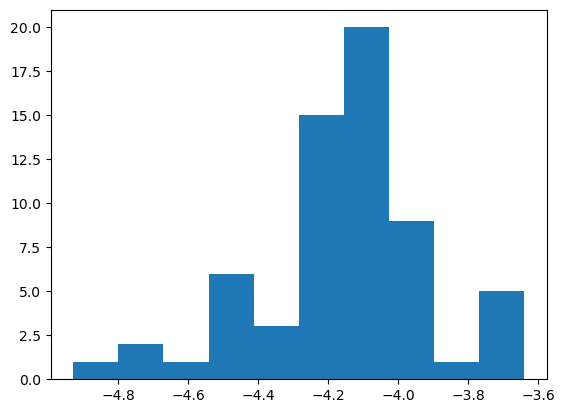

In [13]:
import matplotlib.pyplot as plt
plt.hist(df_rif_lineage_pred["pred_log2_MIC"])

In [10]:
np.exp2(-3.6391904)

0.08025914514426061

In [7]:
import numpy as np

In [8]:
np.exp2(-4.22241)

0.0535707758289189

# Association Between Predicted MIC and Saliency Score

In [41]:
drug = "RIF"
vcf_dir = os.path.join(data_path, drug, "inSilico_analysis/synthetic_VCF")

In [35]:
RIF_rpoBC_scores = sparse.load_npz(os.path.join(results_path, "RIF_rpoBC/saliency/quant/genetic_scores_unpooled_nuc.npy.npz")).todense()
BASE_TO_COLUMN = {'A': 0, 'C': 1, 'T': 2, 'G': 3, '-': 4}

RIF_rpoBC_saliency_df = pd.read_csv("Rifampicin/rpoBC_saliency_results.csv")
RIF_rpoBC_saliency_df["Pos"] = [int(float(val)) if val.replace('.', '').isnumeric() else val for val in RIF_rpoBC_saliency_df["Pos"].values]

In [36]:
def get_max_min_scores_for_pos(idx, scores_matrix, alt_nuc):
    
    max_scores_dict = dict(zip(BASE_TO_COLUMN.keys(), np.max(scores_matrix[:, :, idx, 0], axis=0)))
    min_scores_dict = dict(zip(BASE_TO_COLUMN.keys(), np.min(scores_matrix[:, :, idx, 0], axis=0)))

    # score for the actual alternative allele
    max_allele_score = max_scores_dict[alt_nuc]
    min_allele_score = min_scores_dict[alt_nuc]
    
    return max_allele_score, min_allele_score

In [44]:
most_frequent_nonsyn = ['rpoB_p.Ser450Gln', 'rpoB_p.Met434Ile', 'rpoB_p.Asp435Gly',
       'rpoB_p.His445Pro', 'rpoB_p.Arg448Gln', 'rpoB_p.Ser450Met',
       'rpoC_p.Gly594Glu', 'rpoB_p.Val695Leu', 'rpoC_p.Ala172Val',
       'rpoC_p.Arg173Arg', 'rpoC_p.Pro601Leu', 'rpoB_p.Ile491Leu',
       'rpoB_p.Glu250Gly']

most_frequent_nonsyn_df = df_rif_pred.query("mutation in @most_frequent_nonsyn").reset_index(drop=True)
most_frequent_nonsyn_df.sort_values("MIC", ascending=False)

,log_MIC,mutation,confidence,genome_index,MIC,Max_score,Min_score
4,4.686055,rpoB_p.Ser450Met,2) Assoc w R - Interim,"761154,761155",25.742049,1.622132,-0.164605
5,4.022343,rpoB_p.Ser450Gln,2) Assoc w R - Interim,"761154,761155",16.249721,0.271922,0.000000
1,2.939822,rpoB_p.His445Pro,2) Assoc w R - Interim,761140,7.673168,1.502243,0.000000
0,1.754466,rpoB_p.Arg448Gln,2) Assoc w R - Interim,761149,3.374015,2.323448,0.000000
2,0.253896,rpoB_p.Asp435Gly,2) Assoc w R - Interim,761110,1.192423,0.276530,-0.467400
3,-2.621839,rpoB_p.Met434Ile,2) Assoc w R - Interim,761108,0.162460,0.000000,-0.090518
6,-2.975815,rpoB_p.Ile491Leu,3) Uncertain significance,761277,0.127113,0.000000,-0.069218
8,-3.969505,rpoB_p.Val695Leu,5) Not assoc w R,761889,0.063835,0.000000,0.000000
7,-4.092366,rpoB_p.Glu250Gly,5) Not assoc w R,760555,0.058624,0.002915,0.000000


In [38]:
most_frequent_syn = ['rpoC_c.1626C>G', 'rpoB_c.3225T>C', 'mazF2_c.-4753G>A',
       'rpoB_c.2628T>G', 'rpoB_c.309C>T', 'rpoC_c.162G>C']

df_rif_pred.query("mutation in @most_frequent_syn")

,log_MIC,mutation,confidence,genome_index,MIC


In [270]:
# for i, row in most_frequent_nonsyn_df.iterrows():
    
#     if row["MIC"] < 0.5:
#         most_frequent_nonsyn_df.loc[i, "plot_score"] = row["Min_score"]
#     else:
#         most_frequent_nonsyn_df.loc[i, "plot_score"] = row["Max_score"]

# most_frequent_nonsyn_df

In [39]:
df_rif_pred.head()

,log_MIC,mutation,confidence,genome_index,MIC
0,4.410317,rpoB_p.Gln432Lys,1) Assoc w R,761100,21.263637
1,4.144792,rpoB_p.Gln432Pro,1) Assoc w R,761101,17.689135
2,2.688850,rpoB_p.Ser441Leu,1) Assoc w R,761128,6.447993
3,3.664820,rpoB_p.Gln432Leu,1) Assoc w R,761101,12.682964
4,2.804300,rpoB_p.Phe433dup,1) Assoc w R,761102,6.985193


In [42]:
for i, row in df_rif_pred.iterrows():
    
    vcf_reader = vcf.Reader(filename=os.path.join(vcf_dir, f"{row['mutation']}.vcf"))
    combined_max_score = []
    combined_min_score = []
    
    #print(row['mutation'])
    
    for record in vcf_reader:

        pos = record.POS
        ref_allele = str(record.REF)
        alt_allele = str(record.ALT[0])

        # index in the scores matrix
        idx = RIF_rpoBC_saliency_df.loc[RIF_rpoBC_saliency_df["Pos"]==pos].index.values[0]
            
        if len(ref_allele) == 1:
            
            # SNP
            if len(alt_allele) == 1:
                
                assert h37Rv_seq.seq[pos-1] == record.REF
                # print(pos, record.REF, alt_allele)
                max_allele_score, min_allele_score = get_max_min_scores_for_pos(idx, RIF_rpoBC_scores, alt_allele)
                
                # update the running totals -- single score added for each record
                combined_max_score.append(max_allele_score)
                combined_min_score.append(min_allele_score)
            
            # insertion
            else:
                for k, nuc in enumerate(alt_allele):
                    adj_idx = idx + k + 1
                    max_allele_score, min_allele_score = get_max_min_scores_for_pos(adj_idx, RIF_rpoBC_scores, nuc)
                    combined_max_score.append(max_allele_score)
                    combined_min_score.append(min_allele_score)
                    
        else:
            
            # deletion   
            if len(alt_allele) == 1:
                                
                # the first nucleotide is the alternative allele. Then the rest are gap characters
                for k, nuc in enumerate(ref_allele):
                    
                    adj_idx = idx + k + 1
                    
                    if k == 0:
                        nuc = alt_allele
                    else:
                        nuc = "-"
                    
                    max_allele_score, min_allele_score = get_max_min_scores_for_pos(adj_idx, RIF_rpoBC_scores, nuc)
                    combined_max_score.append(max_allele_score)
                    combined_min_score.append(min_allele_score)
               
            # complex indel
            else:
                
                print(f"Did not process {pos}, {ref_allele}, {alt_allele}")
                combined_max_score = [np.nan]
                combined_min_score = [np.nan]
                
#                 if ref_allele[0] == alt_allele[0]:
                    
#                     print(pos, ref_allele, alt_allele)
                    
#                     # insertion
#                     if len(alt_allele) > len(ref_allele):
                        
#                         for k, nuc in enumerate(ref_allele):
#                             adj_idx = idx + k + 1
                           
#                     # deletion
#                     if len(ref_allele) > len(alt_allele):
                    
#                         for k, nuc in enumerate(alt_allele):
                    
#                 else:
#                     print(f"Did not process {pos}, {ref_allele}, {alt_allele}")

    df_rif_pred.loc[i, ["Max_score", "Min_score"]] = [np.mean(combined_max_score), np.mean(combined_min_score)]
    
    
# for i, row in df_rif_pred.iterrows():
    
#     if row["Max_score"] > 0:
#         if row["Min_score"] < 0:
#             df_rif_pred.loc[i, "Mean_score"] = np.mean([row["Max_score"], row["Mean_score"]])
#         else:
#             df_rif_pred.loc[i, "Mean_score"] = row["Max_score"]
#     else:
#         if row["Min_score"] < 0:
#             df_rif_pred.loc[i, "Mean_score"] = row["Min_score"]
#         else:
#             df_rif_pred.loc[i, "Mean_score"] = 0

Did not process 761099, CCAATTCATGGAC, CCAT
Did not process 761105, CATGGACCAGAAC, CATC
Did not process 761084, CACCAGCCAG, CAAA
Did not process 761108, GGACCAG, GGAG


In [2]:
# def combine_score_across_multiple_sites(saliency_df, multi_site_str):

#     split_sites = multi_site_str.split(",")
#     sig_score_sites = []

#     for site in split_sites:

#         site = int(site)
#         if len(saliency_df.query("POS==@site & Max_Sig == 1")) > 0:
#             max_score = saliency_df.query("POS==@site & Max_Sig == 1").Max.values[0]
#         else:
#             max_score = None

#         if len(saliency_df.query("POS==@site & Min_Sig == 1")) > 0:
#             min_score = saliency_df.query("POS==@site & Min_Sig == 1").Min.values[0]
#         else:
#             min_score = None

#         # if both Max and Min are significant, take the mean
#         if max_score is not None:
#             if min_score is not None:
#                 sig_score_sites.append(np.mean([max_score, min_score]))
#             else:
#                 sig_score_sites.append(max_score)
#         else:
#             if min_score is not None:
#                 sig_score_sites.append(min_score)
#             else:
#                 sig_score_sites.append(0)
    
#     # take the sum of significant sites because the effects are likely additive (mean will underestimate effects)
#     return np.sum(sig_score_sites)

# def add_saliency_scores(plot_df):
    
#     for i, row in plot_df.iterrows():

#         # combine scores across sites for indels
#         if len(row["REF"]) > 1 or len(row["ALT"]) > 1:

#             pos = row["POS"]
#             search_idx = plot_df.query("POS==@pos").index.values[0]
#             diff_len = np.abs(len(row["REF"]) - len(row["ALT"]))

#             max_sig_df = plot_df.iloc[search_idx:search_idx+diff_len].query("Max_Sig==1")
#             if len(max_sig_df) > 0:
#                 max_score = np.max(max_sig_df["Max"])
#             else:
#                 max_score = 0

#             min_sig_df = plot_df.iloc[search_idx:search_idx+diff_len].query("Min_Sig==1")
#             if len(min_sig_df) > 0:
#                 min_score = np.min(min_sig_df["Min"])
#             else:
#                 min_score = 0

#             # because we're considering multiple sites, take the sum
#             plot_df.loc[i, "saliency_score"] = np.sum([max_score, min_score])
            
#         else:
#             if "," in row["genome_index"]:
#                 plot_df.loc[i, "saliency_score"] = combine_score_across_multiple_sites(plot_df, row["genome_index"])
#             else:
#                 if row["Max_Sig"] == 1 and row["Min_Sig"] == 0:
#                     plot_df.loc[i, "saliency_score"] = row["Max"]

#                 elif row["Max_Sig"] == 0 and row["Min_Sig"] == 1:
#                     plot_df.loc[i, "saliency_score"] = row["Min"]

#                 elif row["Max_Sig"] == 1 and row["Min_Sig"] == 1:
#                     plot_df.loc[i, "saliency_score"] = np.mean([row["Max"], row["Min"]])
#                 else:
#                     plot_df.loc[i, "saliency_score"] = 0
                            
#     # if a mutation requires more than one SNV, then there will be multiple rows. But the saliency scores have now been combined, so drop the duplicates 
#     # (they will have the same value in the saliency_score field)
#     plot_df = plot_df.drop_duplicates("mutation", keep="first").reset_index(drop=True)

#     # nothing should be NaN anywhere in the dataframe
#     #assert len(plot_df.dropna()) == len(plot_df)
#     print(plot_df.shape)
    
#     return plot_df

# def get_saliency_scores_to_plot_saliency(pred_df,
#                                          vcf_df,
#                                          saliency_df,
#                                         ):
    
#     # present in both dataframes, so remove it before merging
#     if "confidence" in saliency_df.columns:
#         del saliency_df["confidence"]
    
#     if "POS" not in pred_df.columns:
#         pred_df = pred_df.merge(vcf_df[["mutation", "gene", "POS", "REF", "ALT"]], on="mutation", how="left").reset_index(drop=True)
    
#     # clean up the columns
#     del_cols = ["saliency_score", "drug", "WHO", "Lineage_SNP"]

#     for col in del_cols:
#         if col in pred_df.columns:
#             del pred_df[col]
            
#     if "POS" not in saliency_df.columns:
#         saliency_df["POS"] = [int(float(val)) if val.replace(".", "").isnumeric() else val for val in saliency_df["Pos"].values]
    
#     pred_df = pred_df.merge(saliency_df, on="POS", how="left")
#     pred_df = add_saliency_scores(pred_df)
#     return pred_df

In [161]:
print(df_rif_pred.shape)
RIF_rpoBC_saliency = pd.read_csv("Rifampicin/rpoBC_saliency_results.csv")

df_RIF_saliency_plot = get_saliency_scores_to_plot_saliency(df_rif_pred,
                                                            rpoB_ALL_NEW,
                                                            RIF_rpoBC_saliency
                                                           )

print(df_RIF_saliency_plot.shape)

(711, 7)
(711, 21)
(711, 21)


In [ ]:
print(df_mxf_pred.shape)
MXF_gyrBA_saliency = pd.read_csv("Moxifloxacin/gyrBA_saliency_results.csv")

df_MXF_saliency_plot = get_saliency_scores_to_plot_saliency(df_mxf_pred,
                                                            gyrBA_ALL_NEW,
                                                            MXF_gyrBA_saliency
                                                           )

print(df_MXF_saliency_plot.shape)

# Correlation Between Predicted MIC and Saliency Scores for Mutation IN the Training Dataset

In [154]:
def perform_correlation_permutation_test(x, y, corr_func, num_reps=1000):
    
    # 1. Shuffle data pairs
    # 2. Compute correlation coefficient R on the shuffled set
    # 3. Repeat N times and see how many times the permuted Rs are as extreme as the true value

    true_val = corr_func(x, y)[0]
    permuted_corrs = []
    
    for _ in range(num_reps):

        y_permute = y.copy()
        np.random.shuffle(y_permute)
        permuted_corrs.append(corr_func(x, y_permute)[0])
    
    if true_val > 0:
        return true_val, permuted_corrs, np.mean(permuted_corrs > true_val)
    else:
        return true_val, permuted_corrs, np.mean(permuted_corrs < true_val)

In [176]:
def saliency_scatter_plot(df, x_var="saliency_score", y_var="log_MIC", corr_type="Spearman", saveName=None):
    
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.scatterplot(data=df, 
                    x=x_var, 
                    y=y_var, 
                    hue="confidence", 
                    #hue_order=["1) Assoc w R", "2) Assoc w R - Interim", "3) Uncertain significance", "4) Not assoc w R - Interim", "5) Not assoc w R"],
                    hue_order=np.sort(df["confidence"].unique()),
                    s=35, edgecolors="black", linewidths=0.5, alpha=0.7, palette="colorblind", ax=ax
                   )

    x = df[x_var].values
    y = df[y_var].values
    
    if corr_type == "Pearson":
        corr_func = st.pearsonr
    else:
        corr_func = st.spearmanr
        
    corr, permuted_corrs, pval = perform_correlation_permutation_test(x, y, corr_func)

    plt.title(f"{len(df)} WHO Mutations\n{corr_type} R = {np.round(corr, 2)}, p-value = {pval}")
    plt.axhline(y=np.log2(0.5), color="black", linestyle="dashed", linewidth=1, label="CC = 0.5 µg/mL")
    plt.xlabel("Mutation Saliency Score")

    ax.set_yticks(ticks=ax.get_yticks(), labels=np.round(2**(ax.get_yticks()), 2).astype(str))
    plt.ylabel("Predicted MIC (µg/mL)")
    plt.ylim(y.min()*1.2, y.max()*1.2)

    ax.legend(bbox_to_anchor=(1, 1))
    sns.despine()
    # plt.tight_layout()
    
    if saveName is not None:
        if not os.path.isdir(os.path.dirname(saveName)):
            os.makedirs(os.path.dirname(saveName))
        plt.savefig(saveName, dpi=300, bbox_inches='tight')
    else:
        plt.show()

In [222]:
df_rif_pred.query("Max_score == 0 & Min_score < 0").confidence.unique()

array(['2) Assoc w R - Interim', '3) Uncertain significance',
       '5) Not assoc w R'], dtype=object)

In [223]:
df_rif_pred.query("Max_score == 0 & Min_score < 0")

,log_MIC,mutation,confidence,genome_index,MIC,Max_score,Min_score,Mean_score
34,-4.092037,rpoB_p.Gln429His,2) Assoc w R - Interim,761093,0.058637,0.0,-0.151196,-0.151196
35,-0.512426,rpoB_p.Asp435Ala,2) Assoc w R - Interim,761110,0.701043,0.0,-1.344943,-1.344943
40,-4.077726,rpoB_p.Thr427Ile,2) Assoc w R - Interim,761086,0.059222,0.0,-0.018991,-0.018991
47,-2.990615,rpoB_p.Lys446Gln,2) Assoc w R - Interim,761142,0.125816,0.0,-0.599680,-0.599680
60,-2.621839,rpoB_p.Met434Ile,2) Assoc w R - Interim,761108,0.162460,0.0,-0.090518,-0.090518
...,...,...,...,...,...,...,...,...
680,-4.110909,rpoB_p.Lys944Asn,3) Uncertain significance,762638,0.057875,0.0,-0.014099,-0.014099
682,-4.097178,rpoB_p.Asn963Ser,3) Uncertain significance,762694,0.058429,0.0,-0.002042,-0.002042
688,-4.134403,rpoB_c.-169T>C,3) Uncertain significance,759638,0.056940,0.0,-0.014920,-0.014920
700,-4.095988,rpoB_p.Ile542Lys,3) Uncertain significance,"761431,761432",0.058477,0.0,-0.000410,-0.000821


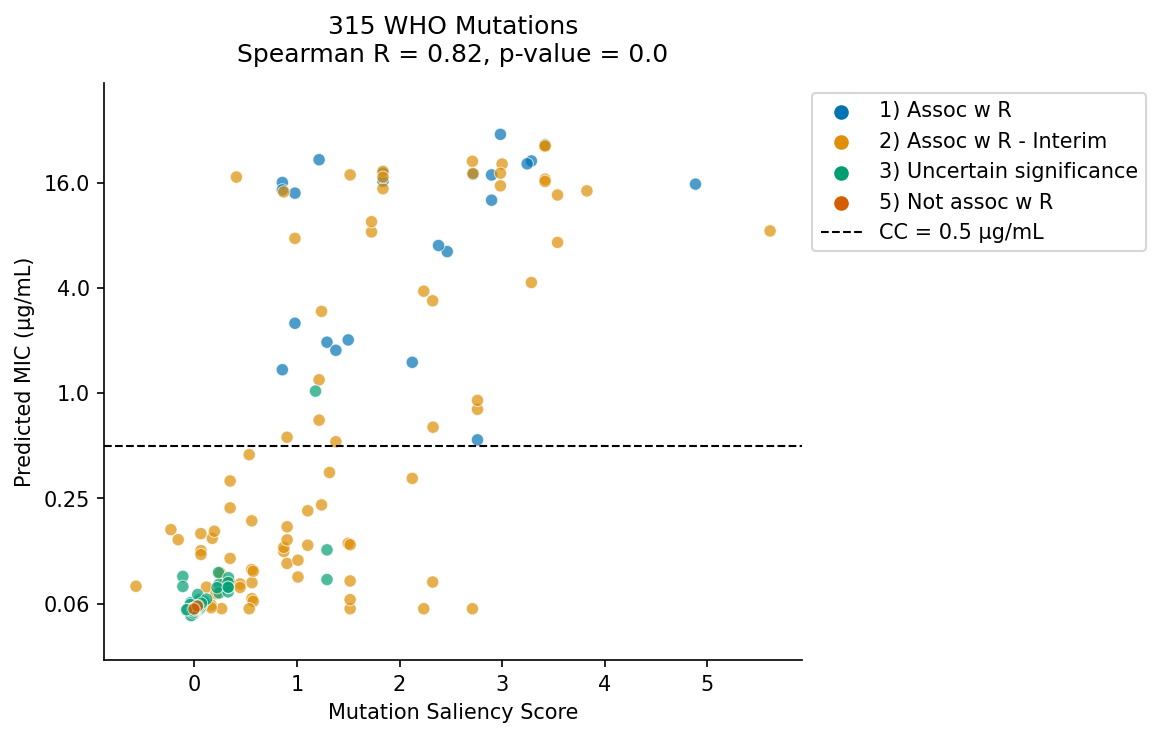

In [171]:
# only plot sites with at least one significant saliency score because the others are not reliable
saliency_scatter_plot(df_RIF_saliency_plot.query("Max_Sig == 1 | Min_Sig == 1"), 
                      corr_type="Spearman", 
                      #saveName="Rifampicin/insilico_mutagenesis/MIC_saliency_scatter.png"
                     )

In [ ]:
# R-associated mutations predicted susceptible
df_rif_saliency_plot.query("confidence=='1) Assoc w R' & log_MIC < -1")

,log_MIC,mutation,confidence,genome_index,MIC,gene,POS,REF,ALT,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020,saliency_score
5,-1.675691,rpoB_p.His445Asn,1) Assoc w R,761139,0.313016,rpoB,761139,C,A,rpoBC,761139.0,5.481325,-2.495282,1.0,1.0,1,0,0,5.481325


In [124]:
# uncertain mutation that predicts resistance
thresh = np.log(0.5)
df_rif_saliency_plot.query("log_MIC > @thresh and confidence.str.contains('3')")

,log_MIC,mutation,confidence,genome_index,gene,POS,REF,ALT,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020,saliency_score
699,0.039532,rpoB_p.Ile491Tyr,3) Uncertain significance,"761277,761278",rpoB,761277,A,T,rpoBC,761277.0,2.801617,-0.215066,1.0,1.0,1,0,0,1.181174


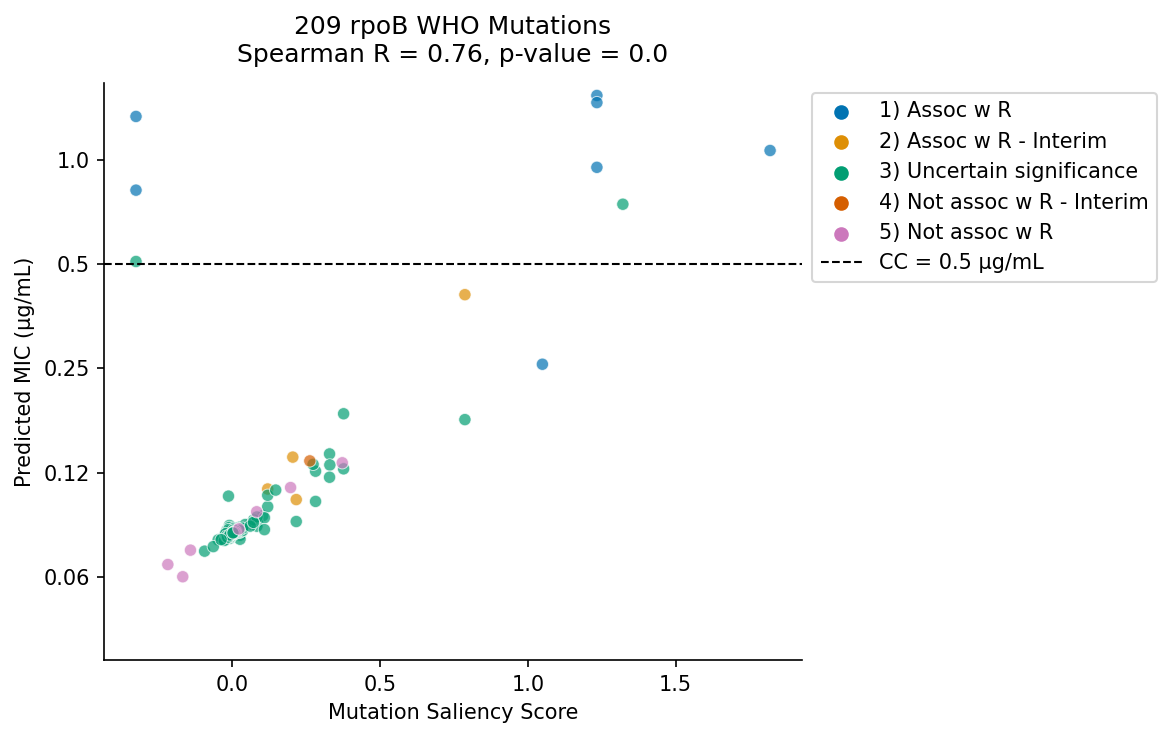

In [120]:
# only plot sites with at least one significant saliency score because the others are not reliable
saliency_scatter_plot(df_MXF_saliency_plot.query("Max_Sig == 1 | Min_Sig == 1"), 
                      corr_type="Spearman", 
                      #saveName="Rifampicin/insilico_mutagenesis/MIC_saliency_scatter.png"
                     )

In [125]:
df_MXF_saliency_plot.query("saliency_score < 0 & log_MIC > @thresh")

,log_MIC,mutation,confidence,genome_index,gene,POS,REF,ALT,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020,saliency_score
1,0.417849,gyrA_p.Asp94Gly,1) Assoc w R,7582,gyrA,7582,A,G,gyrBA,7582.0,1.247441,-0.325217,0.0,1.0,1,0,0,-0.325217
3,-0.289461,gyrA_p.Asp94Ala,1) Assoc w R,7582,gyrA,7582,A,C,gyrBA,7582.0,1.247441,-0.325217,0.0,1.0,1,0,0,-0.325217


# Further Investigation of the Group 2 Mutations with Low Saliency Scores or Low Predicted MICs

### Hypothesis: Low saliency = not in the training dataset.
### Low predicted MIC: IDK!


761134 is the only (1/11) category 1 site without a significant positive saliency score in the RIF CNN

In [231]:
plot_df.query("dataset==1 & MIC_pred < @thresh & saliency_score > 2 & confidence.str.contains('|'.join(['1', '2']))")

,mutation,MIC_pred,genome_index,WHO_genome_index,confidence,POS,gene,variant,REF,ALT,Gene,Max,Min,Mean,Max_Sig,Min_Sig,REF_len,ALT_len,saliency_score,dataset
10,rpoB_p.Gln432His,-1.063436,761102,761102,2) Assoc w R - Interim,761102,rpoB,p.Gln432His,A,T,rpoBC,2.071347,0.000000,0.001046,1.0,0.0,1,1,2.071347,1
14,rpoB_p.His445Asn,-1.661120,761139,761139,1) Assoc w R,761139,rpoB,p.His445Asn,C,A,rpoBC,3.437077,0.000000,0.103309,1.0,0.0,1,1,3.437077,1
29,rpoB_p.Asp435Ala,-0.963358,761110,761110,2) Assoc w R - Interim,761110,rpoB,p.Asp435Ala,A,C,rpoBC,4.191139,0.000000,0.223620,1.0,0.0,1,1,4.191139,1
33,rpoB_p.Asp435His,-1.884073,761109,761109,2) Assoc w R - Interim,761109,rpoB,p.Asp435His,G,C,rpoBC,2.973908,-0.722329,0.037628,1.0,1.0,1,1,2.973908,1
47,rpoB_p.Leu430Arg,-1.703787,761095,761095,2) Assoc w R - Interim,761095,rpoB,p.Leu430Arg,T,G,rpoBC,2.659062,0.000000,0.015638,1.0,0.0,1,1,2.659062,1


In [232]:
search_df = plot_df.query("MIC_pred < @thresh & saliency_score > 2 & confidence.str.contains('|'.join(['1', '2']))")
print(search_df.shape)
search_df = search_df[(search_df["REF"].apply(lambda x: len(x) == 1)) & (search_df["ALT"].apply(lambda x: len(x) == 1))]
print(search_df.shape)

(7, 20)
(6, 20)


In [233]:
scores = sparse.load_npz("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoBC/saliency/quant/genetic_scores_unpooled_nuc.npy.npz").todense()
# num_samples x 5 nucleotides x longest_locus x num_loci
scores.shape

(7480, 5, 7814, 1)

In [234]:
rif_rpoBC_df = rif_rpoBC_df.reset_index(drop=True)
BASE_TO_COLUMN = {'A': 0, 'C': 1, 'T': 2, 'G': 3, '-': 4}

def plot_nuc_scores_single_pos(pos):
    
    search_idx = rif_rpoBC_df.query("Pos==@pos").index.values[0]
    ref = plot_df.query("POS==@pos")["REF"].unique()[0]

    if rif_rpoBC_df.query("Pos==@pos")["Max_Sig"].values[0] == 1:
        scores_by_nuc = dict(zip(BASE_TO_COLUMN.keys(), np.max(scores[:, :, search_idx, :], axis=0).flatten()))

    elif rif_rpoBC_df.query("Pos==@pos")["Min_Sig"].values[0] == 1:
        scores_by_nuc = dict(zip(BASE_TO_COLUMN.keys(), np.min(scores[:, :, search_idx, :], axis=0).flatten()))

    else:
        raise ValueError(f"{pos} does not have a significant score!")

    plot_df_single_site = plot_df.query("POS==@pos")[["mutation", "MIC_pred", "ALT"]]
    y_col = "MIC_pred"
    
#     plot_df_single_site = rpoBC_seqDF[["Isolate", pos]]
#     plot_df_single_site = plot_df_single_site.merge(df_rif[["ROLLINGDB_ID", "RIF_midpoint"]], left_on="Isolate", right_on="ROLLINGDB_ID", how="inner")

#     plot_df_single_site = pd.DataFrame(plot_df_single_site.groupby(pos)["RIF_midpoint"].mean()).reset_index().rename(columns={pos:"ALT"})
    # y_col = "RIF_midpoint"

    plot_df_single_site["saliency"] = plot_df_single_site["ALT"].map(scores_by_nuc)
    print(plot_df_single_site.sort_values("MIC_pred"))

    fig, ax = plt.subplots(figsize=(3, 2))
    sns.scatterplot(data=plot_df_single_site, x="saliency", y=y_col, ax=ax)
    plt.title(f"POS: {pos}, REF nucleotide: {ref}")

    for _, row in plot_df_single_site.iterrows():
        if row["ALT"] != ref:
            plt.text(row["saliency"]+0.05, row[y_col], row["ALT"])

    sns.despine()
    plt.show()

In [ ]:
pos = 761110
search_idx = rif_rpoBC_df.query("Pos==@pos").index.values[0]
ref = plot_df.query("POS==@pos")["REF"].unique()[0]
ref

'A'

In [ ]:
scores.shape

(7480, 5, 7814, 1)

In [ ]:
# this is what we store / plot
np.max(np.sum(scores, axis=1), axis=0).shape

(7814, 1)

In [ ]:
np.squeeze(np.max(scores, axis=0)).shape

(5, 7814)

In [ ]:
np.squeeze(np.max(scores, axis=0))

array([[0.0000000e+00, 6.3485255e-05, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 1.9839880e-04, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00]], dtype=float32)

In [ ]:
np.squeeze(X_h37rv).shape

(5, 7814)

In [ ]:
plt.plot()

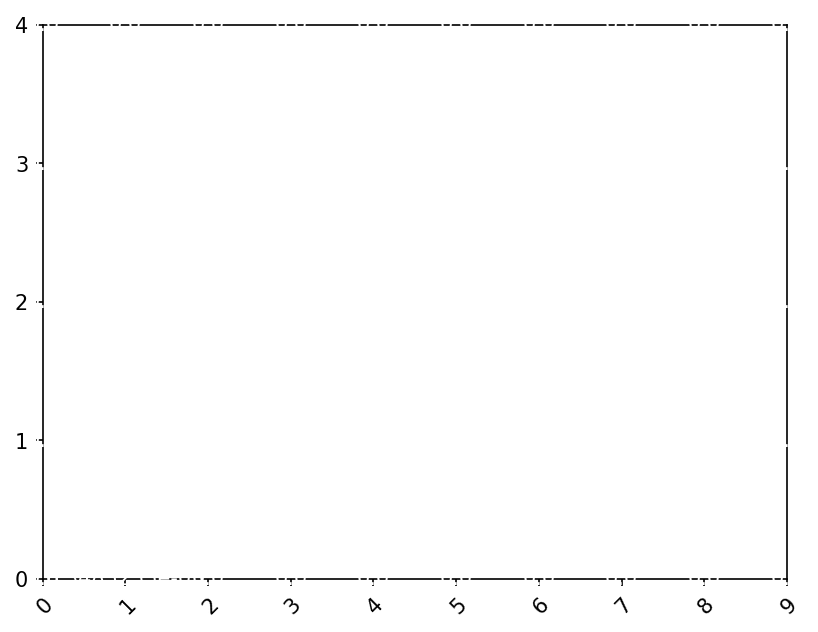

In [120]:
nucleotides = BASE_TO_COLUMN.keys()
positions = np.arange(1, 7814+1)[:10]

max_scores = np.squeeze(np.max(scores, axis=0))

fig, ax = plt.subplots()
# im = ax.imshow(max_scores)

# Show all ticks and label them with the respective list entries
ax.set_xticks(np.arange(len(positions)))
ax.set_yticks(np.arange(len(nucleotides)))

# Rotate the tick labels and set their alignment.
plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
         rotation_mode="anchor")

# Loop over data dimensions and create text annotations.
for i in range(len(nucleotides)):
    for j in range(len(positions)):
        text = ax.text(j, i, max_scores[i, j],
                       ha="center", va="center", color="w")

In [236]:
output_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoBC"
X_h37rv = sparse.load_npz(os.path.join(output_path, 'pkl_sparse_ref.npz')).todense()
X_h37rv.shape

(1, 5, 7814, 1)

In [237]:
# check that the base to column indexing is correct
for idx in range(X_h37rv.shape[2]):
    
    pos = rif_rpoBC_df.loc[idx, "Pos"]
    ref = rpoBC_seqDF.loc["MT_H37Rv", pos]
    
    if not BASE_TO_COLUMN[ref] == np.where(np.squeeze(X_h37rv)[:, idx]==1)[0][0]:
        print(idx)

In [239]:
search_df

,mutation,MIC_pred,genome_index,WHO_genome_index,confidence,POS,gene,variant,REF,ALT,Gene,Max,Min,Mean,Max_Sig,Min_Sig,REF_len,ALT_len,saliency_score,dataset
10,rpoB_p.Gln432His,-1.063436,761102,761102,2) Assoc w R - Interim,761102,rpoB,p.Gln432His,A,T,rpoBC,2.071347,0.000000,0.001046,1.0,0.0,1,1,2.071347,1
14,rpoB_p.His445Asn,-1.661120,761139,761139,1) Assoc w R,761139,rpoB,p.His445Asn,C,A,rpoBC,3.437077,0.000000,0.103309,1.0,0.0,1,1,3.437077,1
29,rpoB_p.Asp435Ala,-0.963358,761110,761110,2) Assoc w R - Interim,761110,rpoB,p.Asp435Ala,A,C,rpoBC,4.191139,0.000000,0.223620,1.0,0.0,1,1,4.191139,1
33,rpoB_p.Asp435His,-1.884073,761109,761109,2) Assoc w R - Interim,761109,rpoB,p.Asp435His,G,C,rpoBC,2.973908,-0.722329,0.037628,1.0,1.0,1,1,2.973908,1
47,rpoB_p.Leu430Arg,-1.703787,761095,761095,2) Assoc w R - Interim,761095,rpoB,p.Leu430Arg,T,G,rpoBC,2.659062,0.000000,0.015638,1.0,0.0,1,1,2.659062,1
49,rpoB_p.Leu452Gln,-1.203364,761161,761161,2) Assoc w R - Interim,761161,rpoB,p.Leu452Gln,T,A,rpoBC,2.145033,0.000000,0.017396,1.0,0.0,1,1,2.145033,0


In [248]:
rpoB_ALL_VCF.query("POS==761139").sort_values("mutation")

,drug,WHO_genome_index,confidence,mutation,POS,gene,variant,REF,ALT,Gene,Max,Min,Mean,Max_Sig,Min_Sig,WHO,Lineage_SNP,REF_len,ALT_len
16,RIF,761139,1) Assoc w R,rpoB_p.His445Asn,761139,rpoB,p.His445Asn,C,A,rpoBC,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
18,RIF,761139,1) Assoc w R,rpoB_p.His445Asp,761139,rpoB,p.His445Asp,C,G,rpoBC,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
19,RIF,761139,1) Assoc w R,rpoB_p.His445Cys,761139,rpoB,p.His445Cys,C,T,rpoBC,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
21,RIF,761139,2) Assoc w R - Interim,rpoB_p.His445Gly,761139,rpoB,p.His445Gly,C,G,rpoBC,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
23,RIF,761139,2) Assoc w R - Interim,rpoB_p.His445Phe,761139,rpoB,p.His445Phe,C,T,rpoBC,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
20,RIF,761139,1) Assoc w R,rpoB_p.His445Ser,761139,rpoB,p.His445Ser,C,A,rpoBC,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
22,RIF,761139,2) Assoc w R - Interim,rpoB_p.His445Thr,761139,rpoB,p.His445Thr,C,A,rpoBC,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
17,RIF,761139,1) Assoc w R,rpoB_p.His445Tyr,761139,rpoB,p.His445Tyr,C,T,rpoBC,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1


In [252]:
rpoB_ALL.query("mutation=='rpoB_p.His445Ser'")

,drug,WHO_genome_index,confidence,mutation,POS,gene,variant,REF,ALT,Gene,Pos,Max,Min,Mean,Max_Sig,Min_Sig,WHO,Lineage_SNP,REF_len,ALT_len
20,RIF,761139,1) Assoc w R,rpoB_p.His445Ser,761139,rpoB,p.His445Ser,C,A,rpoBC,761139,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
50,RIF,761140,1) Assoc w R,rpoB_p.His445Ser,761140,rpoB,p.His445Ser,A,G,rpoBC,761140,4.169374,0.0,0.040140,1.0,0.0,1,0,1,1


In [253]:
rpoB_ALL.query("mutation=='rpoB_p.His445Thr'")

,drug,WHO_genome_index,confidence,mutation,POS,gene,variant,REF,ALT,Gene,Pos,Max,Min,Mean,Max_Sig,Min_Sig,WHO,Lineage_SNP,REF_len,ALT_len
22,RIF,761139,2) Assoc w R - Interim,rpoB_p.His445Thr,761139,rpoB,p.His445Thr,C,A,rpoBC,761139,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
53,RIF,761140,2) Assoc w R - Interim,rpoB_p.His445Thr,761140,rpoB,p.His445Thr,A,C,rpoBC,761140,4.169374,0.0,0.040140,1.0,0.0,1,0,1,1


In [254]:
rpoB_ALL.query("mutation=='rpoB_p.His445Cys'")

,drug,WHO_genome_index,confidence,mutation,POS,gene,variant,REF,ALT,Gene,Pos,Max,Min,Mean,Max_Sig,Min_Sig,WHO,Lineage_SNP,REF_len,ALT_len
19,RIF,761139,1) Assoc w R,rpoB_p.His445Cys,761139,rpoB,p.His445Cys,C,T,rpoBC,761139,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
49,RIF,761140,1) Assoc w R,rpoB_p.His445Cys,761140,rpoB,p.His445Cys,A,G,rpoBC,761140,4.169374,0.0,0.040140,1.0,0.0,1,0,1,1


In [255]:
rpoB_ALL.query("mutation=='rpoB_p.His445Gly'")

,drug,WHO_genome_index,confidence,mutation,POS,gene,variant,REF,ALT,Gene,Pos,Max,Min,Mean,Max_Sig,Min_Sig,WHO,Lineage_SNP,REF_len,ALT_len
21,RIF,761139,2) Assoc w R - Interim,rpoB_p.His445Gly,761139,rpoB,p.His445Gly,C,G,rpoBC,761139,3.437077,0.0,0.103309,1.0,0.0,1,0,1,1
52,RIF,761140,2) Assoc w R - Interim,rpoB_p.His445Gly,761140,rpoB,p.His445Gly,A,G,rpoBC,761140,4.169374,0.0,0.040140,1.0,0.0,1,0,1,1


            mutation  MIC_pred ALT  saliency
14  rpoB_p.His445Asn -1.661120   A  0.000000
20  rpoB_p.His445Thr  0.403495   A  0.000000
18  rpoB_p.His445Ser  0.857502   A  0.000000
19  rpoB_p.His445Gly  1.638188   G  1.461783
21  rpoB_p.His445Phe  1.679750   T  1.677972
17  rpoB_p.His445Cys  1.761852   T  1.677972
16  rpoB_p.His445Asp  1.784891   G  1.461783
15  rpoB_p.His445Tyr  1.877036   T  1.677972


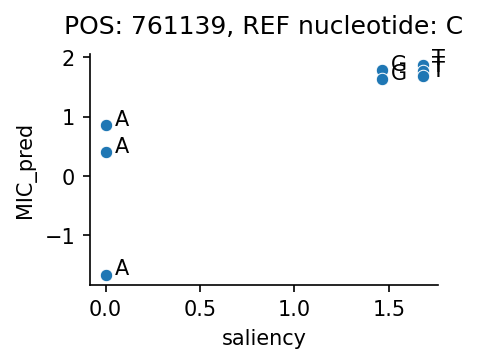

            mutation  MIC_pred ALT  saliency
29  rpoB_p.Asp435Ala -0.963358   C  0.000000
30  rpoB_p.Asp435Gly -0.617019   G  0.000000
31  rpoB_p.Asp435Leu  1.278635   T  1.948339
28  rpoB_p.Asp435Phe  1.684420   T  1.948339
27  rpoB_p.Asp435Val  1.743449   T  1.948339


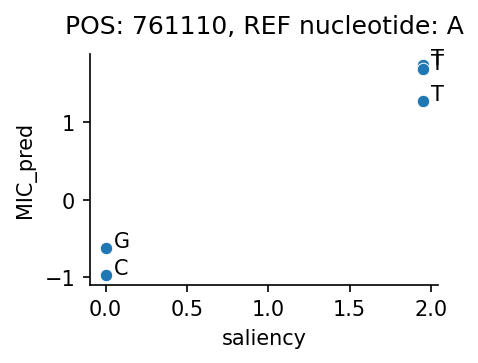

            mutation  MIC_pred ALT  saliency
33  rpoB_p.Asp435His -1.884073   C  0.000000
32  rpoB_p.Asp435Tyr  0.021469   T  1.823904


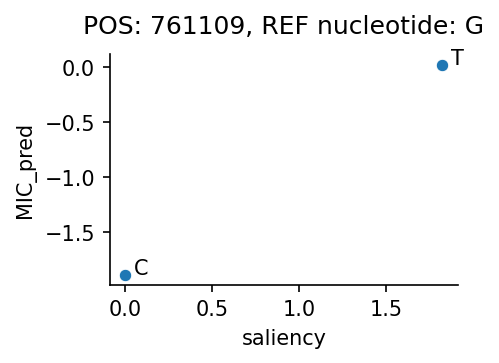

            mutation  MIC_pred ALT  saliency
47  rpoB_p.Leu430Arg -1.703787   G  0.135575
46  rpoB_p.Leu430Pro -0.011871   C  1.299761


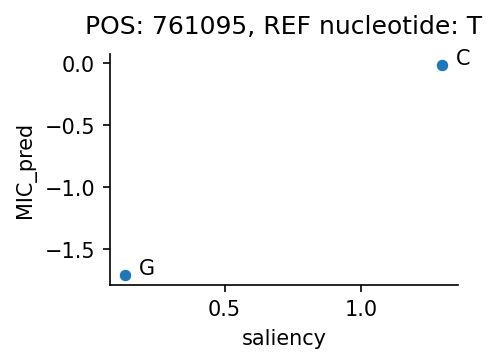

            mutation  MIC_pred ALT  saliency
49  rpoB_p.Leu452Gln -1.203364   A  0.000000
48  rpoB_p.Leu452Pro  0.146495   C  0.848814


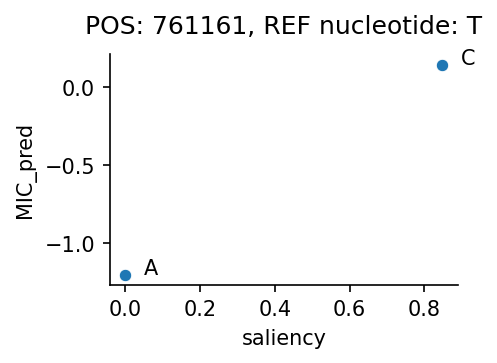

In [242]:
for pos in search_df.POS.unique():
    
    # this one has indels, skip for simplicity rn
    if pos != 761102:
        plot_nuc_scores_single_pos(pos)